In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)
from sklearn.decomposition import PCA

RANDOM_STATE = 42

DATASET_PATH = Path("../dataset/dataset_B.csv")

MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = Path("../figures")

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

MODEL_B_PATH = MODEL_DIR / "isolation_forest_dataset_B.pkl"
SCALER_B_PATH = MODEL_DIR / "standard_scaler_dataset_B.pkl"
FEATURES_B_PATH = MODEL_DIR / "feature_columns_dataset_B.pkl"
CALIBRATION_B_PATH = MODEL_DIR / "score_calibration_dataset_B.pkl"

SCORED_OUTPUT_PATH = OUTPUT_DIR / "dataset_B_ml_scored.csv"
EVALUATION_OUTPUT_PATH = OUTPUT_DIR / "dataset_B_ml_evaluation_results.txt"

print("Dataset path:", DATASET_PATH)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)

Dataset path: ..\dataset\dataset_B.csv
Model directory: ..\models
Output directory: ..\outputs
Figure directory: ..\figures


In [2]:
df_B = pd.read_csv(DATASET_PATH)

# Keep label formatting consistent
df_B["priority_label"] = df_B["priority_label"].astype(str).str.strip().str.title()

print("Dataset B loaded successfully.")
print("Shape:", df_B.shape)

print("\nDataset B class distribution:")
print(df_B["priority_label"].value_counts())

print("\nDataset B class ratio:")
print(df_B["priority_label"].value_counts(normalize=True).round(4))

display(df_B.head())

Dataset B loaded successfully.
Shape: (6125, 26)

Dataset B class distribution:
priority_label
Low     4900
High    1225
Name: count, dtype: int64

Dataset B class ratio:
priority_label
Low     0.8
High    0.2
Name: proportion, dtype: float64


,timestamp,host,host_ip,user,source_ip,event_id,scenario_type,priority_label,mitre_technique,rule_level,...,is_after_hours,is_remote_logon,logon_type,asset_criticality,event_4624,event_4625,event_4672,event_4688,event_5140,event_7045
0,2026-05-31 02:37:00,DC01,192.168.79.131,IT-PC01$,192.168.79.133,4624,normal_machine_auth,Low,Benign Activity,3,...,1,1,3,1.0,1,0,0,0,0,0
1,2026-05-18 19:20:00,FINANCE-PC01,192.168.79.132,charlie.it,192.168.79.132,4624,normal_logon,Low,Benign Activity,4,...,0,0,2,0.8,1,0,0,0,0,0
2,2026-05-04 15:19:00,DC01,192.168.79.131,bob.finance,192.168.79.132,4625,single_failed_login,Low,Benign Authentication Noise,5,...,0,0,2,1.0,0,1,0,0,0,0
3,2026-05-15 14:00:00,IT-PC01,192.168.79.133,charlie.it,192.168.79.133,4624,normal_logon,Low,Benign Activity,2,...,0,0,2,0.6,1,0,0,0,0,0
4,2026-05-12 21:06:00,FINANCE-PC01,192.168.79.132,charlie.it,192.168.79.132,4624,normal_logon,Low,Benign Activity,4,...,1,0,2,0.8,1,0,0,0,0,0


In [3]:
# Define metadata and final ML feature columns

METADATA_COLS = [
    "timestamp",
    "host",
    "host_ip",
    "user",
    "source_ip",
    "event_id",
    "scenario_type",
    "priority_label",
    "mitre_technique",
]

FEATURE_COLS = [
    "rule_level",
    "failed_login_count",
    "successful_login_count",
    "same_source_ip_attempts",
    "unique_users_targeted",
    "distinct_hosts_accessed",
    "hour_of_day",
    "is_after_hours",
    "is_remote_logon",
    "logon_type",
    "asset_criticality",
    "event_4624",
    "event_4625",
    "event_4672",
    "event_4688",
    "event_5140",
    "event_7045",
]

print("Metadata columns:", len(METADATA_COLS))
print(METADATA_COLS)

print("\nML feature columns:", len(FEATURE_COLS))
print(FEATURE_COLS)

Metadata columns: 9
['timestamp', 'host', 'host_ip', 'user', 'source_ip', 'event_id', 'scenario_type', 'priority_label', 'mitre_technique']

ML feature columns: 17
['rule_level', 'failed_login_count', 'successful_login_count', 'same_source_ip_attempts', 'unique_users_targeted', 'distinct_hosts_accessed', 'hour_of_day', 'is_after_hours', 'is_remote_logon', 'logon_type', 'asset_criticality', 'event_4624', 'event_4625', 'event_4672', 'event_4688', 'event_5140', 'event_7045']


In [4]:
# Feature checks, duplicate checks, and one-hot event columns

# Create one-hot event columns only if they are missing
for event_id in [4624, 4625, 4672, 4688, 5140, 7045]:
    col_name = f"event_{event_id}"

    if col_name not in df_B.columns:
        df_B[col_name] = (df_B["event_id"] == event_id).astype(int)

missing_features = [col for col in FEATURE_COLS if col not in df_B.columns]
missing_metadata = [col for col in METADATA_COLS if col not in df_B.columns]

duplicate_count = int(df_B.duplicated().sum())

missing_values = df_B.isna().sum()
missing_values = missing_values[missing_values > 0]

print("Missing ML feature columns:", missing_features)
print("Missing metadata columns:", missing_metadata)
print("Exact duplicate rows:", duplicate_count)

print("\nColumns with missing values:")
display(missing_values)

if missing_features:
    raise ValueError(f"Missing ML features: {missing_features}")

if missing_metadata:
    raise ValueError(f"Missing metadata columns: {missing_metadata}")

joblib.dump(FEATURE_COLS, FEATURES_B_PATH)

print("\nDataset checks completed.")
print("Saved feature columns to:", FEATURES_B_PATH)

Missing ML feature columns: []
Missing metadata columns: []
Exact duplicate rows: 0

Columns with missing values:


Series([], dtype: int64)


Dataset checks completed.
Saved feature columns to: ..\models\feature_columns_dataset_B.pkl


In [5]:
# Prepare features, labels, metadata and split the dataset

X_features = df_B[FEATURE_COLS].copy()
evaluation_labels = df_B["priority_label"].copy()
metadata = df_B[METADATA_COLS].copy()

X_train_full, X_test, y_train_full, y_test, meta_train_full, meta_test = train_test_split(
    X_features,
    evaluation_labels,
    metadata,
    test_size=0.20,
    stratify=evaluation_labels,
    random_state=RANDOM_STATE,
)

X_train, X_validation, y_train, y_validation, meta_train, meta_validation = train_test_split(
    X_train_full,
    y_train_full,
    meta_train_full,
    test_size=0.125,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Testing rows:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nValidation label distribution:")
print(y_validation.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

print("\nFirst 10 test indices:")
print(X_test.index[:10].tolist())

Training rows: 4287
Validation rows: 613
Testing rows: 1225

Training label distribution:
priority_label
Low     3430
High     857
Name: count, dtype: int64

Validation label distribution:
priority_label
Low     490
High    123
Name: count, dtype: int64

Testing label distribution:
priority_label
Low     980
High    245
Name: count, dtype: int64

First 10 test indices:
[4969, 2546, 5205, 6055, 2422, 2811, 3716, 5042, 3169, 1798]


In [6]:
# Train scaler on Low baseline rows only

X_train_baseline = X_train[y_train == "Low"].copy()

scaler = StandardScaler()

X_train_baseline_scaled = scaler.fit_transform(X_train_baseline)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Low baseline rows used for training:", len(X_train_baseline))
print("Scaling complete.")

Low baseline rows used for training: 3430
Scaling complete.


In [8]:
# Validate contamination values

contamination_values = [ 0.02, 0.03, 0.07, 0.10, 0.12, 0.15 ]

search_results = []

for contamination in contamination_values:
    candidate_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )

    candidate_model.fit(X_train_baseline_scaled)

    validation_prediction = np.where(
        candidate_model.predict(X_validation_scaled) == -1,
        "High",
        "Low",
    )

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        validation_prediction,
        labels=["Low", "High"],
    ).ravel()

    search_results.append({
        "contamination": contamination,
        "accuracy": accuracy_score(y_validation, validation_prediction),
        "precision_high": precision_score(
            y_validation,
            validation_prediction,
            pos_label="High",
            zero_division=0,
        ),
        "recall_high": recall_score(
            y_validation,
            validation_prediction,
            pos_label="High",
            zero_division=0,
        ),
        "f1_high": f1_score(
            y_validation,
            validation_prediction,
            pos_label="High",
            zero_division=0,
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

contamination_results = pd.DataFrame(search_results).sort_values(
    "f1_high",
    ascending=False,
)

display(contamination_results)

,contamination,accuracy,precision_high,recall_high,f1_high,tn,fp,fn,tp
0,0.02,0.972268,0.927419,0.934959,0.931174,481,9,8,115
1,0.03,0.967374,0.905512,0.934959,0.920000,478,12,8,115
2,0.07,0.951060,0.803922,1.000000,0.891304,460,30,0,123
3,0.10,0.928222,0.736527,1.000000,0.848276,446,44,0,123
4,0.12,0.908646,0.687151,1.000000,0.814570,434,56,0,123
5,0.15,0.887439,0.640625,1.000000,0.780952,421,69,0,123


In [9]:
# Automatically select the best contamination value

# The selected contamination is based on the highest validation F1-score.

BEST_CONTAMINATION = float(
    contamination_results.sort_values(
        by=["f1_high", "recall_high", "precision_high"],
        ascending=False
    ).iloc[0]["contamination"]
)

selected_result = contamination_results[
    contamination_results["contamination"] == BEST_CONTAMINATION
]

print("Automatically selected contamination:", BEST_CONTAMINATION)
display(selected_result)

Automatically selected contamination: 0.02


,contamination,accuracy,precision_high,recall_high,f1_high,tn,fp,fn,tp
0,0.02,0.972268,0.927419,0.934959,0.931174,481,9,8,115


In [10]:
# Train final Isolation Forest model

final_model = IsolationForest(
    n_estimators=200,
    contamination=BEST_CONTAMINATION,
    random_state=RANDOM_STATE,
)

final_model.fit(X_train_baseline_scaled)

print("Final model trained.")

Final model trained.


In [11]:
# Evaluate once on the untouched test set

raw_prediction = final_model.predict(X_test_scaled)

evaluation_prediction = np.where(
    raw_prediction == -1,
    "High",
    "Low",
)

raw_anomaly_score = -final_model.decision_function(X_test_scaled)

test_results = meta_test.copy().reset_index(drop=True)
test_results["priority_label"] = y_test.reset_index(drop=True)
test_results["evaluation_prediction"] = evaluation_prediction
test_results["raw_anomaly_score"] = raw_anomaly_score

display(test_results[
    [
        "timestamp",
        "host",
        "user",
        "source_ip",
        "event_id",
        "scenario_type",
        "priority_label",
        "evaluation_prediction",
        "raw_anomaly_score",
    ]
].head(10))

,timestamp,host,user,source_ip,event_id,scenario_type,priority_label,evaluation_prediction,raw_anomaly_score
0,2026-05-10 08:11:00,DC01,FINANCE-PC01$,192.168.79.132,4624,normal_machine_auth,Low,Low,-0.114939
1,2026-05-12 23:48:00,DC01,alice.finance,192.168.79.132,4625,single_failed_login,Low,Low,-0.050122
2,2026-05-05 21:15:00,FINANCE-PC01,bob.finance,192.168.79.132,4688,normal_client_activity,Low,Low,-0.005578
3,2026-05-27 03:43:00,IT-PC01,bob.finance,192.168.79.133,4624,normal_logon,Low,Low,-0.072336
4,2026-05-02 11:05:00,DC01,charlie.it,192.168.79.133,4625,single_failed_login,Low,Low,-0.079524
5,2026-05-25 05:14:00,DC01,bob.finance,192.168.79.133,4624,odd_hour_normal_login,Low,Low,-0.059961
6,2026-05-11 05:59:00,DC01,bob.finance,192.168.79.134,4625,targeted_brute_force,High,High,0.035066
7,2026-05-28 04:52:00,FINANCE-PC01,Administrator,192.168.79.133,4624,benign_remote_admin,Low,Low,-0.105958
8,2026-05-23 12:03:00,IT-PC01,charlie.it,192.168.79.133,4624,normal_logon,Low,Low,-0.079163
9,2026-05-05 02:58:00,FINANCE-PC01,bob.finance,192.168.79.132,4624,normal_logon,Low,Low,-0.161961


In [12]:
# Calculate final test metrics

cm = confusion_matrix(
    test_results["priority_label"],
    test_results["evaluation_prediction"],
    labels=["Low", "High"],
)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(
    test_results["priority_label"],
    test_results["evaluation_prediction"],
)

precision_high = precision_score(
    test_results["priority_label"],
    test_results["evaluation_prediction"],
    pos_label="High",
    zero_division=0,
)

recall_high = recall_score(
    test_results["priority_label"],
    test_results["evaluation_prediction"],
    pos_label="High",
    zero_division=0,
)

f1_high = f1_score(
    test_results["priority_label"],
    test_results["evaluation_prediction"],
    pos_label="High",
    zero_division=0,
)

labels_test_binary = (
    test_results["priority_label"] == "High"
).astype(int)

roc_auc = roc_auc_score(
    labels_test_binary,
    test_results["raw_anomaly_score"],
)

average_precision = average_precision_score(
    labels_test_binary,
    test_results["raw_anomaly_score"],
)

print("Confusion matrix [Low, High]:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision High: {precision_high:.4f}")
print(f"Recall High: {recall_high:.4f}")
print(f"F1 High: {f1_high:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision: {average_precision:.4f}")

print("\nClassification report:")
print(classification_report(
    test_results["priority_label"],
    test_results["evaluation_prediction"],
    labels=["Low", "High"],
    zero_division=0,
    digits=4,
))

Confusion matrix [Low, High]:
[[960  20]
 [ 10 235]]
TN=960, FP=20, FN=10, TP=235
Accuracy: 0.9755
Precision High: 0.9216
Recall High: 0.9592
F1 High: 0.9400
ROC-AUC: 0.9967
Average Precision: 0.9864

Classification report:
              precision    recall  f1-score   support

         Low     0.9897    0.9796    0.9846       980
        High     0.9216    0.9592    0.9400       245

    accuracy                         0.9755      1225
   macro avg     0.9556    0.9694    0.9623      1225
weighted avg     0.9761    0.9755    0.9757      1225



In [13]:
# Save model artefacts and outputs

joblib.dump(final_model, MODEL_B_PATH)
joblib.dump(scaler, SCALER_B_PATH)
joblib.dump(FEATURE_COLS, FEATURES_B_PATH)

train_low_raw_scores = -final_model.decision_function(X_train_baseline_scaled)

score_calibration = {
    "raw_score_lower": float(np.percentile(train_low_raw_scores, 1)),
    "raw_score_upper": float(np.percentile(train_low_raw_scores, 99)),
}

joblib.dump(score_calibration, CALIBRATION_B_PATH)

test_results.to_csv(SCORED_OUTPUT_PATH, index=False)

with open(EVALUATION_OUTPUT_PATH, "w", encoding="utf-8") as file:
    file.write("Dataset B Isolation Forest Evaluation Results:\n")
    file.write(f"Contamination: {BEST_CONTAMINATION}\n")
    file.write(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")
    file.write(f"Accuracy: {accuracy:.4f}\n")
    file.write(f"Precision High: {precision_high:.4f}\n")
    file.write(f"Recall High: {recall_high:.4f}\n")
    file.write(f"F1 High: {f1_high:.4f}\n")
    file.write(f"ROC-AUC: {roc_auc:.4f}\n")
    file.write(f"Average Precision: {average_precision:.4f}\n")

print("Saved model:", MODEL_B_PATH)
print("Saved scaler:", SCALER_B_PATH)
print("Saved features:", FEATURES_B_PATH)
print("Saved calibration:", CALIBRATION_B_PATH)
print("Saved scored output:", SCORED_OUTPUT_PATH)
print("Saved evaluation output:", EVALUATION_OUTPUT_PATH)
print("\nScore calibration:", score_calibration)

Saved model: ..\models\isolation_forest_dataset_B.pkl
Saved scaler: ..\models\standard_scaler_dataset_B.pkl
Saved features: ..\models\feature_columns_dataset_B.pkl
Saved calibration: ..\models\score_calibration_dataset_B.pkl
Saved scored output: ..\outputs\dataset_B_ml_scored.csv
Saved evaluation output: ..\outputs\dataset_B_ml_evaluation_results.txt

Score calibration: {'raw_score_lower': -0.17806613649688713, 'raw_score_upper': 0.009605063952209166}


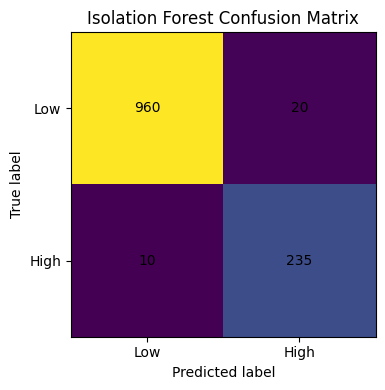

Saved: ..\figures\dataset_B_confusion_matrix.png


In [14]:
# Confusion matrix plot

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Isolation Forest Confusion Matrix")
plt.xticks([0, 1], ["Low", "High"])
plt.yticks([0, 1], ["Low", "High"])

for row in range(2):
    for column in range(2):
        plt.text(column, row, cm[row, column], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

confusion_path = FIGURE_DIR / "dataset_B_confusion_matrix.png"
plt.savefig(confusion_path, dpi=300)
plt.show()

print("Saved:", confusion_path)

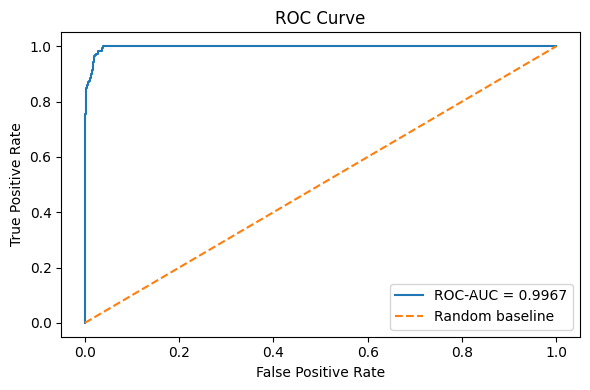

Saved: ..\figures\dataset_B_roc_curve.png


In [15]:
# ROC curve plot

fpr, tpr, _ = roc_curve(
    labels_test_binary,
    test_results["raw_anomaly_score"],
)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

roc_path = FIGURE_DIR / "dataset_B_roc_curve.png"
plt.savefig(roc_path, dpi=300)
plt.show()

print("Saved:", roc_path)

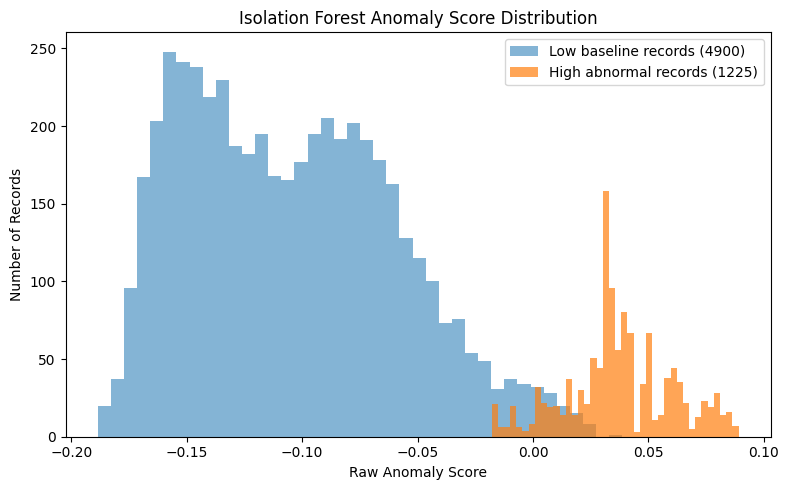

Saved: ..\figures\dataset_B_anomaly_score_distribution.png


In [16]:
# Anomaly score distribution

X_all = df_B[FEATURE_COLS].copy()
X_all_scaled = scaler.transform(X_all)

all_anomaly_scores = -final_model.decision_function(X_all_scaled)

score_df = pd.DataFrame({
    "anomaly_score": all_anomaly_scores,
    "priority_label": df_B["priority_label"].values,
})

low_scores = score_df[score_df["priority_label"] == "Low"]["anomaly_score"]
high_scores = score_df[score_df["priority_label"] == "High"]["anomaly_score"]

plt.figure(figsize=(8, 5))

plt.hist(
    low_scores,
    bins=40,
    alpha=0.55,
    label=f"Low baseline records ({len(low_scores)})",
)

plt.hist(
    high_scores,
    bins=40,
    alpha=0.70,
    label=f"High abnormal records ({len(high_scores)})",
)

plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Raw Anomaly Score")
plt.ylabel("Number of Records")
plt.legend()

plt.tight_layout()

score_dist_path = FIGURE_DIR / "dataset_B_anomaly_score_distribution.png"
plt.savefig(score_dist_path, dpi=300)
plt.show()

print("Saved:", score_dist_path)

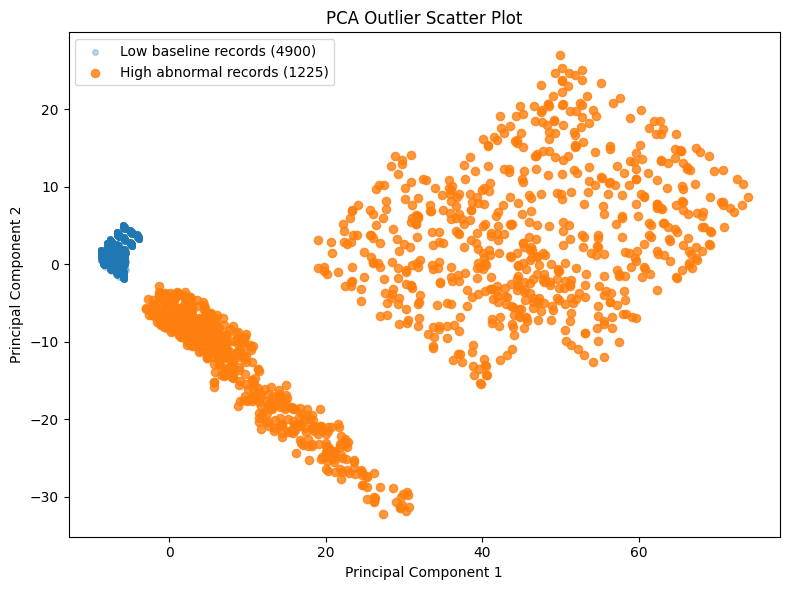

Saved: ..\figures\dataset_B_pca_outlier_scatter.png


In [17]:
# PCA outlier scatter plot
# PCA is used only for visualization.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_all_pca = pca.fit_transform(X_all_scaled)

plot_df = pd.DataFrame({
    "pc1": X_all_pca[:, 0],
    "pc2": X_all_pca[:, 1],
    "priority_label": df_B["priority_label"].values,
})

low_points = plot_df[plot_df["priority_label"] == "Low"]
high_points = plot_df[plot_df["priority_label"] == "High"]

plt.figure(figsize=(8, 6))

plt.scatter(
    low_points["pc1"],
    low_points["pc2"],
    label=f"Low baseline records ({len(low_points)})",
    alpha=0.28,
    s=16,
)

plt.scatter(
    high_points["pc1"],
    high_points["pc2"],
    label=f"High abnormal records ({len(high_points)})",
    alpha=0.80,
    s=35,
)

plt.title("PCA Outlier Scatter Plot")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()

plt.tight_layout()

pca_path = FIGURE_DIR / "dataset_B_pca_outlier_scatter.png"
plt.savefig(pca_path, dpi=300)
plt.show()

print("Saved:", pca_path)

In [18]:
# Review false positives and false negatives

false_positives = test_results[
    (test_results["priority_label"] == "Low")
    & (test_results["evaluation_prediction"] == "High")
]

false_negatives = test_results[
    (test_results["priority_label"] == "High")
    & (test_results["evaluation_prediction"] == "Low")
]

print("False positives:", len(false_positives))
display(false_positives["scenario_type"].value_counts())

print("\nFalse negatives:", len(false_negatives))
display(false_negatives["scenario_type"].value_counts())

False positives: 20


scenario_type
normal_client_activity      9
benign_admin_maintenance    4
odd_hour_normal_login       4
benign_remote_admin         3
Name: count, dtype: int64


False negatives: 10


scenario_type
domain_enumeration    5
sam_dump_activity     3
lateral_movement      2
Name: count, dtype: int64